In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [45]:
df = pd.read_csv('cardio_train.csv',sep = ';')

df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [46]:
df["age"] = np.ceil(df["age"] / 365).astype(int) # age convert to year 

In [47]:
# 1 - women, 2 - men ----- 1: normal, 2: above normal(Middium), 3: well above normal(High) 

In [48]:
df.head() # first five data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,51,2,168,62.0,110,80,1,1,0,0,1,0
1,1,56,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,49,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0


In [49]:
df.tail() # last five data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,53,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,62,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,57,1,170,72.0,120,80,2,1,0,0,1,0


In [50]:
df.info() # total rows, columns, data type , missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [51]:
df.shape

(70000, 13)

In [52]:
df.columns # all columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [53]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,53.837914,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.766821,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,30.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,49.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,59.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
df['age'].mean()

np.float64(53.837914285714284)

In [55]:
df['age'].min()

30

In [56]:
df['age'].max()

65

In [57]:
df.index

RangeIndex(start=0, stop=70000, step=1)

In [58]:
df['height'] # koi pan aek column jova 

0        168
1        156
2        165
3        169
4        156
        ... 
69995    168
69996    158
69997    183
69998    163
69999    170
Name: height, Length: 70000, dtype: int64

In [59]:
df[df["age"] > 70] #data filter age > 50

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [60]:
df[(df["age"] > 50)  & (df["cardio"] == 1)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
1,1,56,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
7,12,62,2,178,95.0,130,90,3,3,0,0,1,1
22,32,64,1,158,90.0,145,85,2,2,0,0,1,1
30,42,51,1,155,105.0,120,80,3,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70.0,130,90,1,1,0,0,1,1
69994,99992,58,1,165,80.0,150,80,1,1,0,0,1,1
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,53,2,183,105.0,180,90,3,1,0,1,0,1


In [61]:
df[(df["ap_hi"] > 140) & (df["cardio"] == 1)] # High Blood Pressure

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
3,3,49,2,169,82.0,150,100,1,1,0,0,1,1
22,32,64,1,158,90.0,145,85,2,2,0,0,1,1
24,35,46,1,170,68.0,150,90,3,1,0,0,1,1
44,59,55,1,154,50.0,170,80,3,1,0,0,1,1
46,61,50,1,162,107.0,150,90,2,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69958,99943,42,2,169,67.0,160,90,1,1,0,0,1,1
69979,99969,62,1,163,74.0,160,100,2,2,0,0,1,1
69992,99990,52,1,161,56.0,170,90,1,1,0,0,1,1
69994,99992,58,1,165,80.0,150,80,1,1,0,0,1,1


In [62]:
df.sort_values("age", ascending=False) # sort by ascending

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
38,52,65,2,162,72.0,130,80,1,1,1,0,1,1
45298,64716,65,2,170,75.0,130,90,3,1,1,0,1,1
45310,64736,65,2,172,75.0,150,80,1,1,0,0,0,1
45284,64688,65,1,159,77.0,120,80,3,1,0,0,1,1
45294,64703,65,2,176,74.0,150,90,2,2,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,142,40,2,164,48.0,110,70,1,2,1,1,1,1
55905,79749,31,1,160,59.0,110,70,1,1,0,0,1,0
30666,43842,30,1,159,59.0,120,80,1,1,0,0,1,0
6219,8850,30,1,175,59.0,120,80,1,1,0,0,1,0


In [63]:
df.sample(10) # random 10 data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
67869,96926,61,2,175,100.0,150,90,1,1,0,0,1,1
7732,11037,62,2,168,93.0,140,90,1,1,0,0,0,1
25668,36638,58,2,172,92.0,150,90,2,2,0,0,1,0
56321,80373,54,1,164,72.0,120,80,1,1,0,0,1,1
47259,67510,45,1,149,67.0,120,80,1,1,0,0,1,0
59454,84888,59,1,146,47.0,130,80,1,2,0,0,0,1
36230,51736,52,2,166,74.0,120,80,1,1,0,1,1,0
49529,70716,58,1,163,59.0,130,70,1,1,0,0,0,0
54761,78134,52,2,169,71.0,130,80,3,1,0,0,1,1
48691,69535,45,1,169,65.0,120,80,1,1,0,0,1,1


In [64]:
df["cardio"].value_counts() # value count and data type

cardio
0    35021
1    34979
Name: count, dtype: int64

In [65]:
df.isnull().sum() # null value joy teno sum

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [66]:
df.duplicated() # duplicated nathi aetle false

0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Length: 70000, dtype: bool

In [67]:
df.describe() # Outlire mate

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,53.837914,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.766821,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,30.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,49.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,59.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [68]:
print("ap_hi minimum:", df["ap_hi"].min())
print("ap_hi maximum:", df["ap_hi"].max())

print("ap_lo minimum:", df["ap_lo"].min())
print("ap_lo maximum:", df["ap_lo"].max())

ap_hi minimum: -150
ap_hi maximum: 16020
ap_lo minimum: -70
ap_lo maximum: 11000


In [69]:
df = df[
    (df["ap_hi"] >= 60) &
    (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 200)
]

In [70]:
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,68775.000000,68775.000000
mean,126.614846,81.382043
std,16.763475,9.676889
min,60.000000,40.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,240.000000,190.000000


In [71]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [73]:
print(X_scaled[:5])

[[-1.7324669  -0.41744909  1.36657846  0.44453876 -0.84586338 -0.99114095
  -0.14281997 -0.53717753 -0.39513718 -0.31065288 -0.23807321  0.49472348]
 [-1.73243223  0.32119879 -0.73175454 -1.0215417   0.75902928  0.79847717
   0.89057755  2.40835844 -0.39513718 -0.31065288 -0.23807321  0.49472348]
 [-1.73239756 -0.26971952 -0.73175454  0.07801864 -0.70630749  0.20193779
  -1.17621749  2.40835844 -0.39513718 -0.31065288 -0.23807321 -2.02133119]
 [-1.73236289 -0.71290824  1.36657846  0.56671213  0.54969546  1.39501654
   1.92397507 -0.53717753 -0.39513718 -0.31065288 -0.23807321  0.49472348]
 [-1.73232822 -0.86063782 -0.73175454 -1.0215417  -1.26453103 -1.58768033
  -2.20961501 -0.53717753 -0.39513718 -0.31065288 -0.23807321 -2.02133119]]


In [74]:
df["ap_lo"].unique() # unique value in "ap_lo" column

array([ 80,  90,  70, 100,  60,  85,  89, 110,  65,  63,  79, 120,  50,
       109,  84, 150,  91,  40,  73,  78,  75,  86,  87,  82,  95,  69,
        74,  97,  81,  83, 119,  93, 105,  99,  77,  59, 140,  92, 108,
       125, 115,  68,  61, 106, 102,  94,  66,  52, 170,  76, 160,  62,
        96, 130, 113,  67,  88, 112, 104,  71,  72,  98,  57, 101,  64,
        45,  58, 126, 103, 180, 121, 114,  53, 111, 118,  56, 182, 107,
        55, 190, 122, 135,  54,  49])

In [75]:
df["ap_hi"].unique() # unique value in "ap_hi" column

array([110, 140, 130, 150, 100, 120, 145, 170, 135, 125,  90, 180, 160,
       133, 190,  80, 122, 169, 126, 158, 123,  70, 161, 147, 115, 137,
       153, 148, 105, 220, 119, 141, 165, 164, 124, 172, 162, 117, 134,
       166, 176, 116, 121, 112, 113, 118, 200, 155, 142, 131, 157, 136,
       146, 138, 159, 109,  85, 106, 129,  93,  95, 179, 156, 168, 132,
       104, 103, 175, 128, 151, 139, 127, 108, 144, 102, 210, 143, 107,
       184, 178, 149, 167, 114, 101,  60, 171, 202, 111, 188, 185, 163,
       173, 154, 177, 174, 240, 191, 197, 152,  96, 193,  99, 196, 230,
       215,  97, 195, 187])

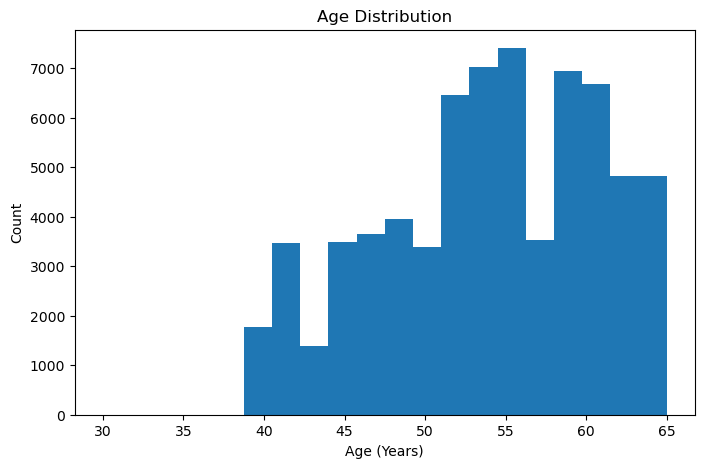

In [76]:
plt.figure(figsize=(8,5)) # Width = 8 અને Height = 5. # Histogram => Continuous Data (age,height,weight)
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()

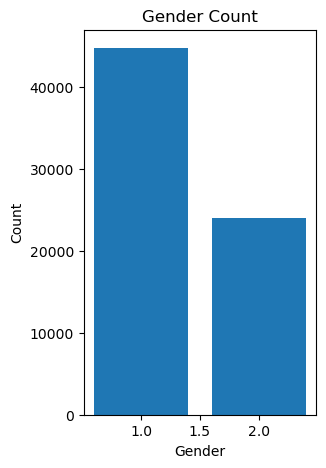

In [77]:
gender = df["gender"].value_counts() # Bar chrt => Categorical Data

plt.figure(figsize=(3,5))
plt.bar(gender.index, gender.values)
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [78]:
# week 3
Y = df["cardio"]
Y

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 68775, dtype: int64

In [79]:
X = df.drop("cardio", axis=1)
X

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,0,51,2,168,62.0,110,80,1,1,0,0,1
1,1,56,1,156,85.0,140,90,3,1,0,0,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0
3,3,49,2,169,82.0,150,100,1,1,0,0,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53,2,168,76.0,120,80,1,1,1,0,1
69996,99995,62,1,158,126.0,140,90,2,2,0,0,1
69997,99996,53,2,183,105.0,180,90,3,1,0,1,0
69998,99998,62,1,163,72.0,135,80,1,2,0,0,0


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_Train data")
print(X_train)
print("-----------------------")
print("X_Test data")
print(X_test)
print("-----------------------")
print("Y_Train data")
print(Y_train)
print("-----------------------")
print("Y_Test data")
print(Y_test)

X_Train data
          id  age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
28345  40519   56       1     170    86.0    120     70            1     1   
11618  16608   42       2     179    92.0    120     80            1     1   
12271  17522   54       1     156    69.0    110     70            1     1   
26364  37664   65       1     163    68.0    140     80            1     1   
13601  19410   58       1     160    62.0    160     90            1     1   
...      ...  ...     ...     ...     ...    ...    ...          ...   ...   
37861  54049   57       1     169    70.0    120     80            1     1   
6384    9083   60       1     161    61.0    130     80            3     1   
55848  79681   55       1     164    73.0    120     80            1     1   
873     1213   63       2     170    78.0    120     70            3     3   
16077  22953   61       2     156    55.0    120     80            1     1   

       smoke  alco  active  
28345      0     0   

In [81]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
model = LogisticRegression()
model

LogisticRegression()

In [84]:
model.fit(X_train, Y_train)

LogisticRegression()

In [85]:
model_filename = 'cardio_model.pkl'
joblib.dump(model, model_filename)

print(f"Model trained successfully and saved as '{model_filename}'!")

Model trained successfully and saved as 'cardio_model.pkl'!


In [131]:
prediction = model.predict(X_test)
prediction

array([0, 0, 1, ..., 0, 1, 0])

In [132]:
print(prediction[:10])

print(Y_test[:10])

[0 0 1 0 0 0 1 0 0 0]
15123    0
21228    0
1391     1
43538    0
110      1
17262    0
65915    0
65126    0
55178    0
26066    0
Name: cardio, dtype: int64
